In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import time

In [11]:
df = pd.read_csv('spambase_csv_Kaggle.csv')
df.dropna(inplace=True)
X = df.drop('class', axis=1)
y = df['class']

In [12]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

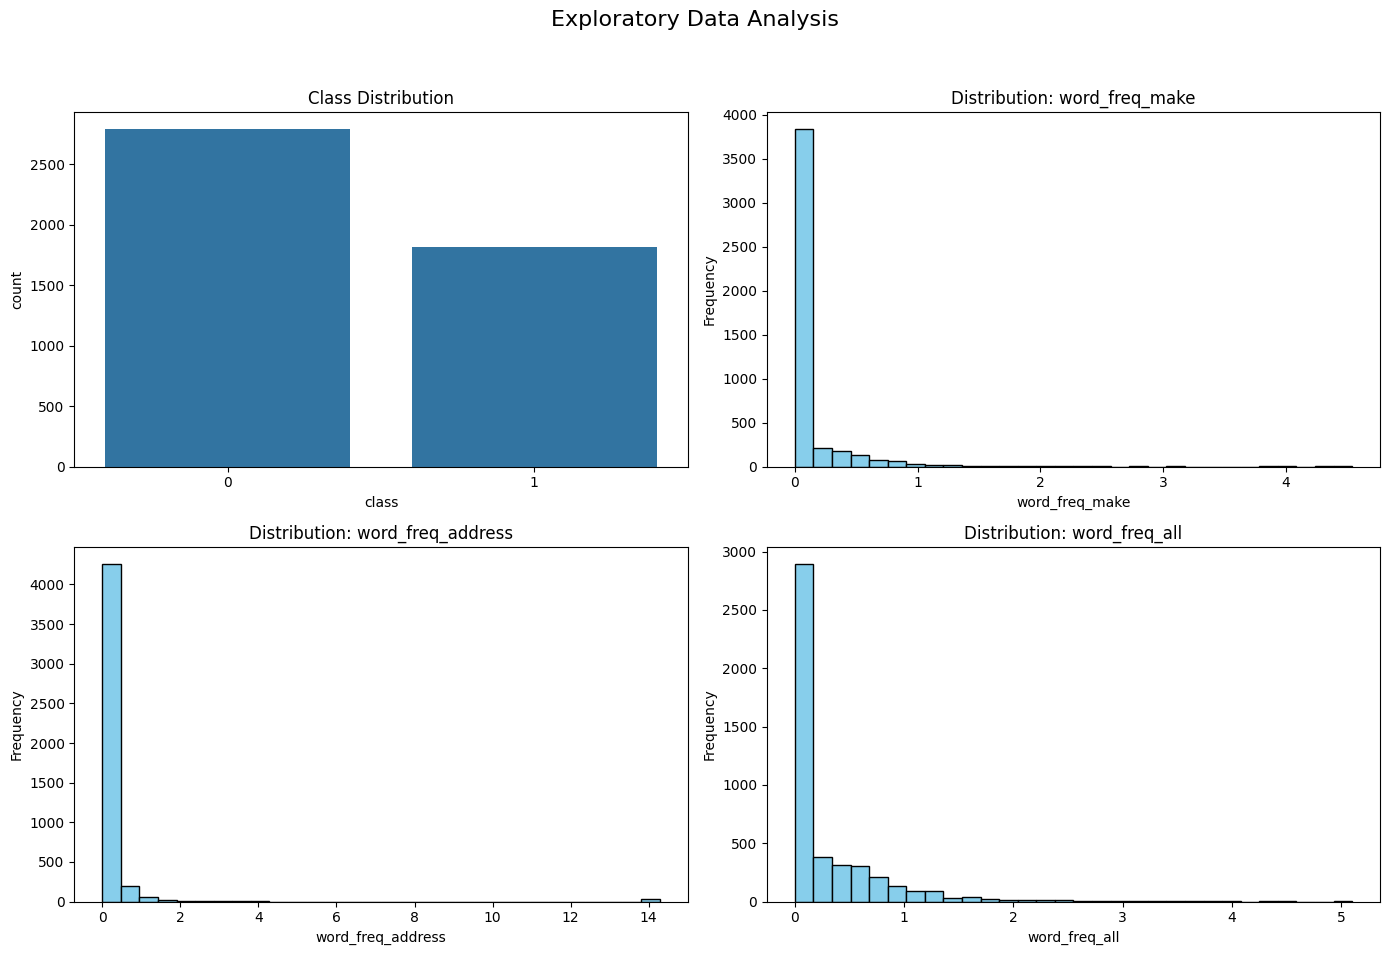

In [13]:
fig_eda, axes_eda = plt.subplots(2, 2, figsize=(14, 10))
fig_eda.suptitle('Exploratory Data Analysis', fontsize=16)

sns.countplot(x='class', data=df, ax=axes_eda[0, 0])
axes_eda[0, 0].set_title('Class Distribution')

features_to_plot = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'capital_run_length_average']
for i, feature in enumerate(features_to_plot):
    if i < 3: # Use remaining subplots
        ax = axes_eda.flatten()[i+1]
        ax.hist(df[feature], bins=30, color='skyblue', edgecolor='black')
        ax.set_title(f'Distribution: {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_plots.eps', format='eps')
plt.show()

In [14]:
# 4. Data Splitting (70% Train, 30% Test)
X_train_std, X_test_std, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(X_minmax, y, test_size=0.3, random_state=42, stratify=y)

# 5. Model Training & Metrics Function
models = {}

In [15]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    start_train = time.time()
    model.fit(X_tr, y_tr)
    end_train = time.time()
    
    start_pred = time.time()
    y_pred = model.predict(X_te)
    # Get probabilities for ROC if available
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    end_pred = time.time()
    
    # Metrics
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return {
        'Name': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1,
        'Specificity': spec, 'False Positive Rate': fpr, 'Training Time': end_train - start_train,
        'Prediction Time': end_pred - start_pred, 'y_pred': y_pred, 'y_prob': y_prob, 'cm': cm
    }

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Best k found: 1


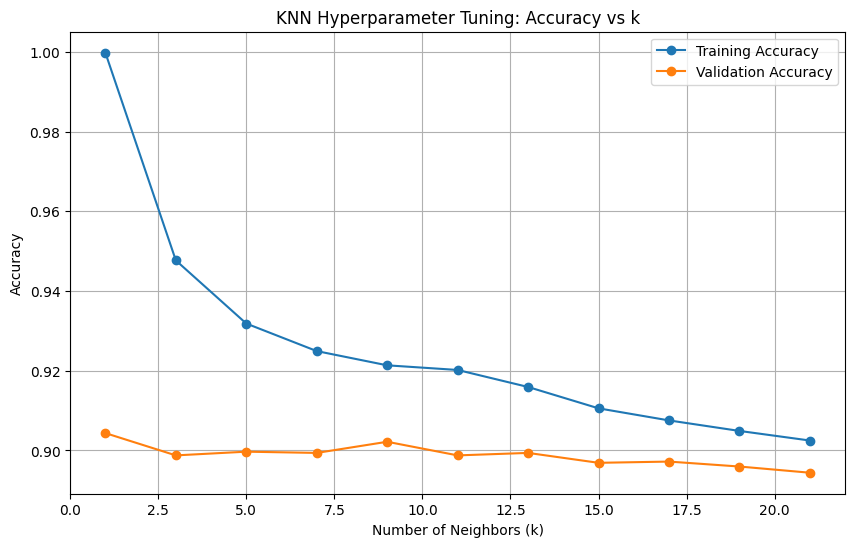

            Name  Accuracy  Precision    Recall  F1 Score  Specificity  \
0     GaussianNB  0.819696   0.700136  0.948529  0.805621     0.735962   
1  MultinomialNB  0.895004   0.942350  0.781250  0.854271     0.968937   
2   KNN_Baseline  0.899348   0.881356  0.860294  0.870698     0.924731   
3     KNN_KDTree  0.895004   0.864717  0.869485  0.867094     0.911589   
4   KNN_BallTree  0.895004   0.864717  0.869485  0.867094     0.911589   

   False Positive Rate  Training Time  Prediction Time  
0             0.264038       0.005461         0.002013  
1             0.031063       0.001035         0.000663  
2             0.075269       0.000465         0.025006  
3             0.088411       0.012923         0.150812  
4             0.088411       0.006445         0.208333  


In [16]:
# Train Naive Bayes Variants
models['GaussianNB'] = evaluate_model('GaussianNB', GaussianNB(), X_train_std, X_test_std, y_train, y_test)
models['MultinomialNB'] = evaluate_model('MultinomialNB', MultinomialNB(), X_train_mm, X_test_mm, y_train_mm, y_test_mm)

# Train Baseline KNN
models['KNN_Baseline'] = evaluate_model('KNN_Baseline', KNeighborsClassifier(), X_train_std, X_test_std, y_train, y_test)

# Hyperparameter Tuning (5-Fold CV)
k_range = list(range(1, 22, 2))
train_scores, val_scores = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(knn, X_train_std, y_train, cv=5, return_train_score=True, scoring='accuracy')
    train_scores.append(scores['train_score'].mean())
    val_scores.append(scores['test_score'].mean())

best_k = k_range[np.argmax(val_scores)]
print(f"Best k found: {best_k}")

# Plot KNN Tuning
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, marker='o', label='Training Accuracy')
plt.plot(k_range, val_scores, marker='o', label='Validation Accuracy')
plt.title('KNN Hyperparameter Tuning: Accuracy vs k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('knn_tuning.eps', format='eps')
plt.show()

# Train Optimized KNNs
models[f'KNN_KDTree'] = evaluate_model(f'KNN_KDTree', KNeighborsClassifier(n_neighbors=best_k, algorithm='kd_tree'), X_train_std, X_test_std, y_train, y_test)
models[f'KNN_BallTree'] = evaluate_model(f'KNN_BallTree', KNeighborsClassifier(n_neighbors=best_k, algorithm='ball_tree'), X_train_std, X_test_std, y_train, y_test)

# 6. Evaluation Table
results_df = pd.DataFrame([{k: v for k, v in m.items() if k not in ['y_pred', 'y_prob', 'cm']} for m in models.values()])
print(results_df)

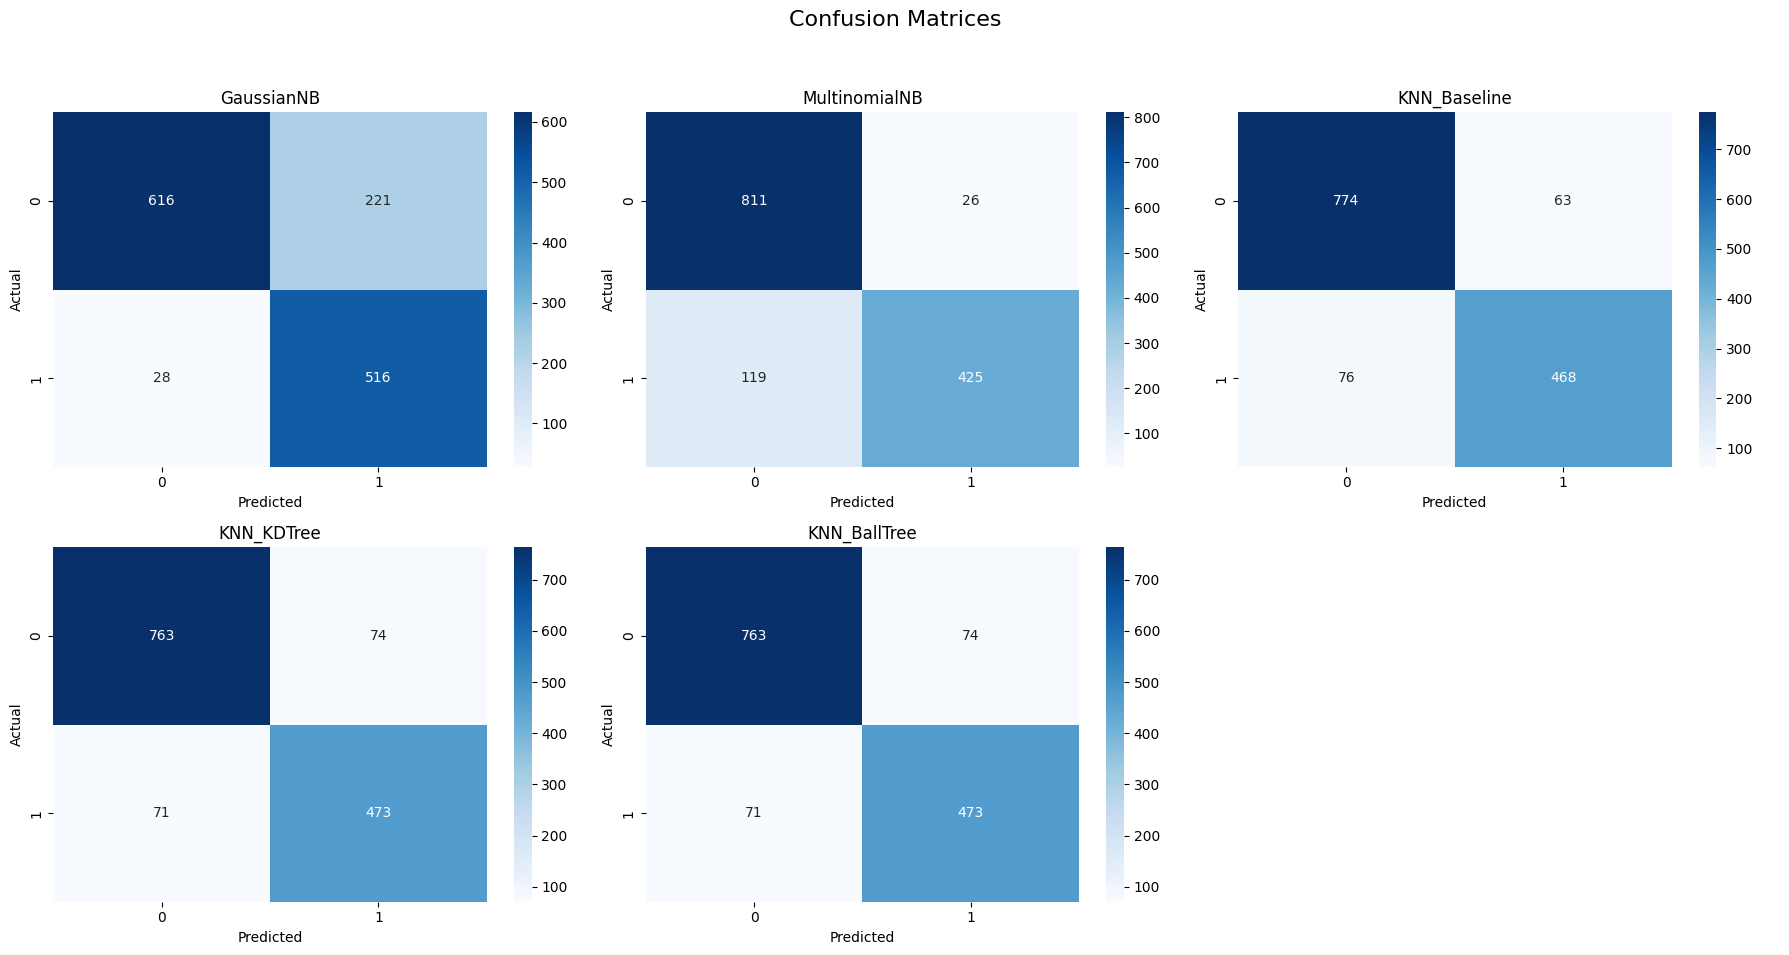

In [17]:
# 7. Visualizations: Confusion Matrices
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 10))
fig_cm.suptitle('Confusion Matrices', fontsize=16)
axes_cm_flat = axes_cm.flatten()

for i, (name, result) in enumerate(models.items()):
    ax = axes_cm_flat[i]
    sns.heatmap(result['cm'], annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

if len(models) < len(axes_cm_flat): axes_cm_flat[-1].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('confusion_matrices.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


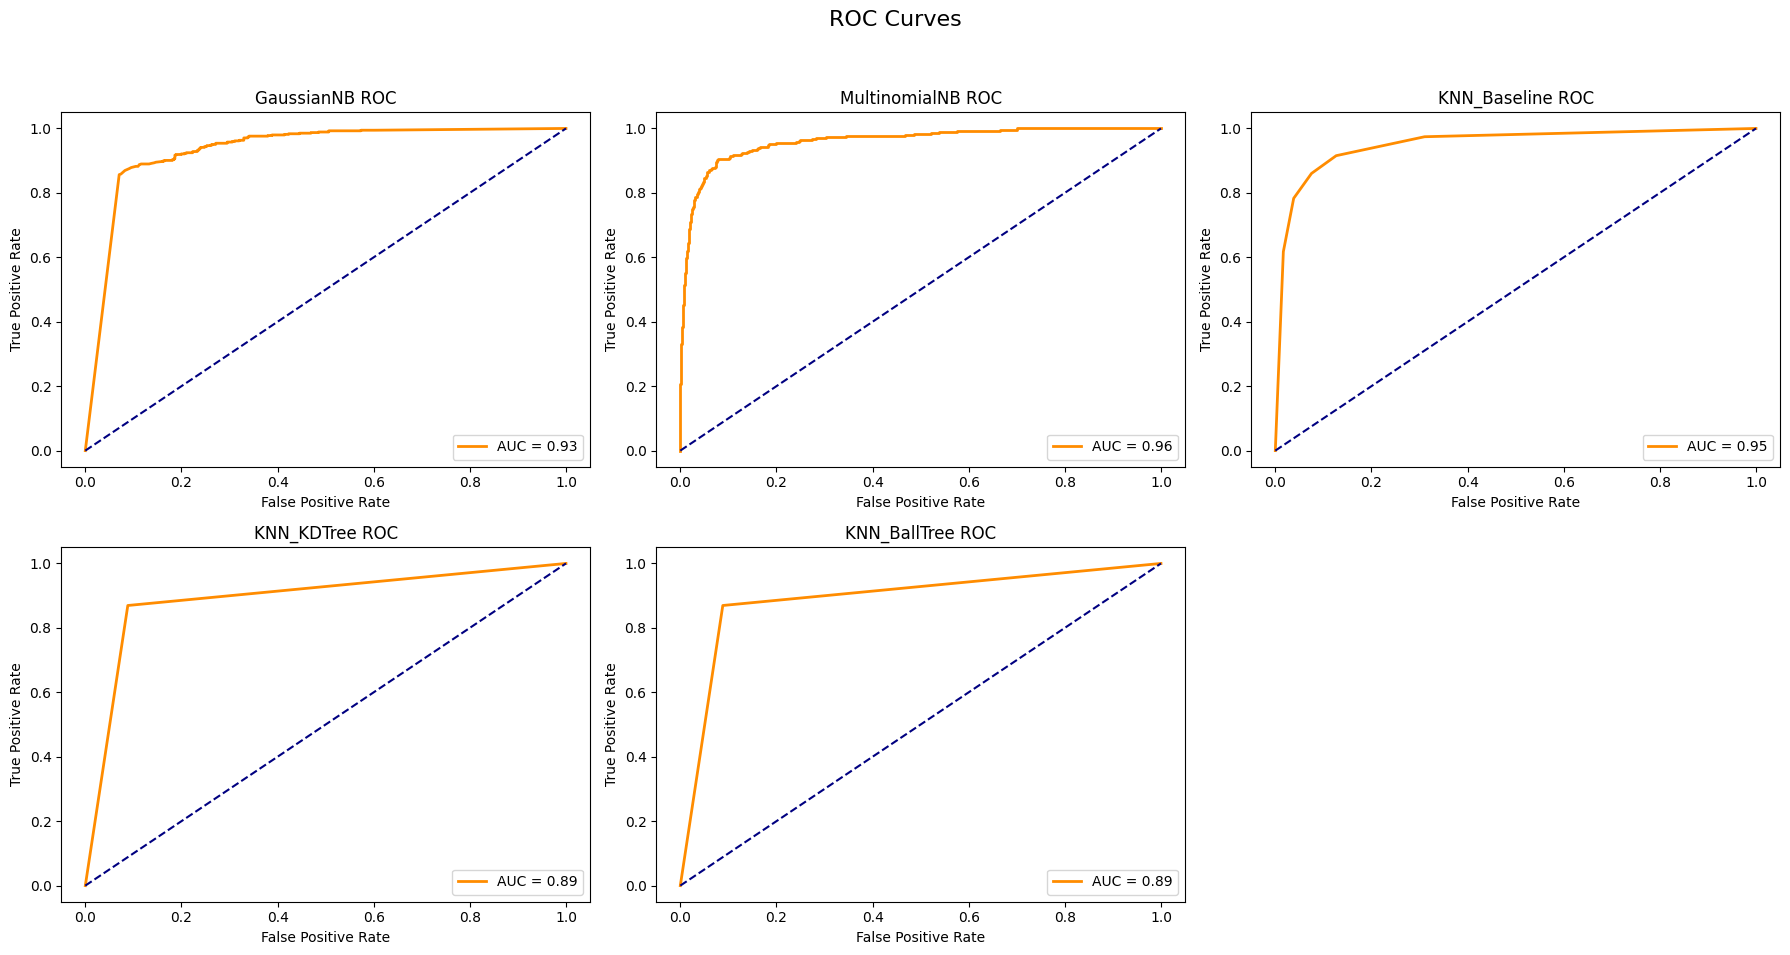

In [18]:
# 8. Visualizations: ROC Curves
fig_roc, axes_roc = plt.subplots(2, 3, figsize=(18, 10))
fig_roc.suptitle('ROC Curves', fontsize=16)
axes_roc_flat = axes_roc.flatten()

for i, (name, result) in enumerate(models.items()):
    ax = axes_roc_flat[i]
    if result['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        ax.plot([0, 1], [0, 1], color='navy', linestyle='--')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{name} ROC')
        ax.legend(loc="lower right")
    else:
        ax.text(0.5, 0.5, "No Probabilities", ha='center')

if len(models) < len(axes_roc_flat): axes_roc_flat[-1].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('roc_curves.eps', format='eps')
plt.show()